# 2. Avaliação do Modelo de Sentimentos

Este notebook carrega o modelo de Regressão Logística treinado e salvo para avaliar sua performance no conjunto de dados de teste.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from src.data_processing import carregar_dados, preparar_dados
from src.config import settings

In [2]:
print(f"Carregando dados de: {settings.data_path}")

df = carregar_dados(settings.data_path)
df = preparar_dados(df)

X = df['texto_limpo']
y = df['sentimento_label']

_, X_teste, _, y_teste = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

print(f"Quantidade de reviews para avaliação: {len(X_teste)}")

Carregando dados de: /home/pedroa-bg/Linguagens/python/python_p_DataScience/projeto_AnaliseSentimentos_ML/data/raw/dataset.csv
Quantidade de reviews para avaliação: 122


In [3]:
modelo_carregado = joblib.load(settings.model_path)

print("Modelo carregado com sucesso!")

Modelo carregado com sucesso!


In [4]:
y_pred = modelo_carregado.predict(X_teste)

acuracia = accuracy_score(y_teste, y_pred)
report = classification_report(y_teste, y_pred, target_names=['Negativo', 'Positivo'])

print(f"Acurácia do Modelo: {acuracia:.2%}\n")
print("Relatório de Classificação:\n")
print(report)

Acurácia do Modelo: 90.16%

Relatório de Classificação:

              precision    recall  f1-score   support

    Negativo       0.94      0.84      0.89        58
    Positivo       0.87      0.95      0.91        64

    accuracy                           0.90       122
   macro avg       0.91      0.90      0.90       122
weighted avg       0.91      0.90      0.90       122



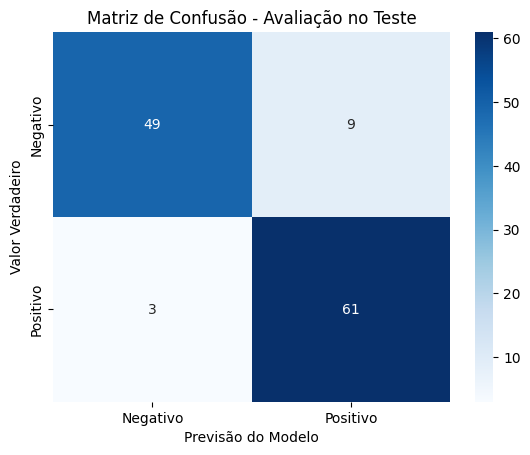

In [5]:
# Visualizar a Matriz de Confusão
cm = confusion_matrix(y_teste, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negativo', 'Positivo'],
            yticklabels=['Negativo', 'Positivo'])

plt.xlabel('Previsão do Modelo')
plt.ylabel('Valor Verdadeiro')
plt.title('Matriz de Confusão - Avaliação no Teste')
plt.show()

### Conclusões da Avaliação

1. **Acurácia Geral:** O modelo acertou 90.16% das classificações, o que indica uma excelente capacidade de generalização.
2. **Falsos Positivos vs Falsos Negativos:** Observando a Matriz de Confusão, o modelo cometeu uma taxa baixa de erros (9 falsos positivos e 3 falsos negativos) considerando a quantidade de acertos. A proximidade dos números indica que o modelo apresenta um comportamento equilibrado, sem tendência significativa de favorecer uma das classes.
3. **Desempenho das Classes:** As métricas de precision, recall e F1-score ficaram próximas para as duas classes, indicando que o modelo mantém um desempenho consistente tanto na identificação de reviews positivos quanto negativos.
